In [ ]:
import pandas as pd
import numpy as np
print("Pandas version:", pd.__version__)

Pandas version: 2.2.2


In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("=== IMPORTANT CHECK ===")
print("Shape of dataframe:", df.shape)
print("Columns exactly as loaded:")
print(df.columns.tolist())
print("\nFirst 3 rows (just to confirm):")
print(df.head(3))

=== IMPORTANT CHECK ===
Shape of dataframe: (891, 12)
Columns exactly as loaded:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 3 rows (just to confirm):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


In [ ]:
# Safe version: drop only columns that actually exist
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# See which ones are present
existing_cols = [col for col in columns_to_drop if col in df.columns]
print("Dropping these columns:", existing_cols)

if existing_cols:
    df = df.drop(columns=existing_cols)
    print("Drop completed successfully")
else:
    print("No columns to drop — already removed?")

print("\nColumns left after drop:")
print(df.columns.tolist())

Dropping these columns: []
No columns to drop — already removed?

Columns left after drop:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with most common value 'S'
df['Embarked'] = df['Embarked'].fillna('S')

print("Missing values after filling:")
print(df.isna().sum())

print("\nShape now:", df.shape)

Missing values after filling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Shape now: (891, 8)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Sex: male → 0, female → 1 (usually)
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# Embarked: S, C, Q → 0, 1, 2 (order doesn't matter much here)
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

print("First 6 rows after encoding:")
print(df.head(6))

print("\nSex value counts (should be ~ 0=male, 1=female):")
print(df['Sex'].value_counts())

print("\nEmbarked value counts:")
print(df['Embarked'].value_counts())

First 6 rows after encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2
5         0       3    1  28.0      0      0   8.4583         1

Sex value counts (should be ~ 0=male, 1=female):
Sex
1    577
0    314
Name: count, dtype: int64

Embarked value counts:
Embarked
2    646
0    168
1     77
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)     # all columns except target
y = df['Survived']                  # only the target column

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing
    random_state=42,        # same split every time
    stratify=y              # keep same % of survived/not-survived in train & test
)

print("Training samples:", X_train.shape[0])   # should be ~712
print("Test samples:    ", X_test.shape[0])    # should be ~179
print("\nFeatures (columns in X):")
print(X_train.columns.tolist())

Training samples: 712
Test samples:     179

Features (columns in X):
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)   # increased iterations just in case
log_model.fit(X_train, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,
    n_jobs=-1              # use all CPU cores → faster
)
rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [ ]:
# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)

# Probabilities (needed for ROC-AUC)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

# Function to print metrics nicely
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} Performance ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")

print_metrics("Logistic Regression", y_test, y_pred_log, y_prob_log)
print_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf)


=== Logistic Regression Performance ===
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244
ROC-AUC:   0.8520

=== Random Forest Performance ===
Accuracy:  0.8268
Precision: 0.8065
Recall:    0.7246
F1-score:  0.7634
ROC-AUC:   0.8277


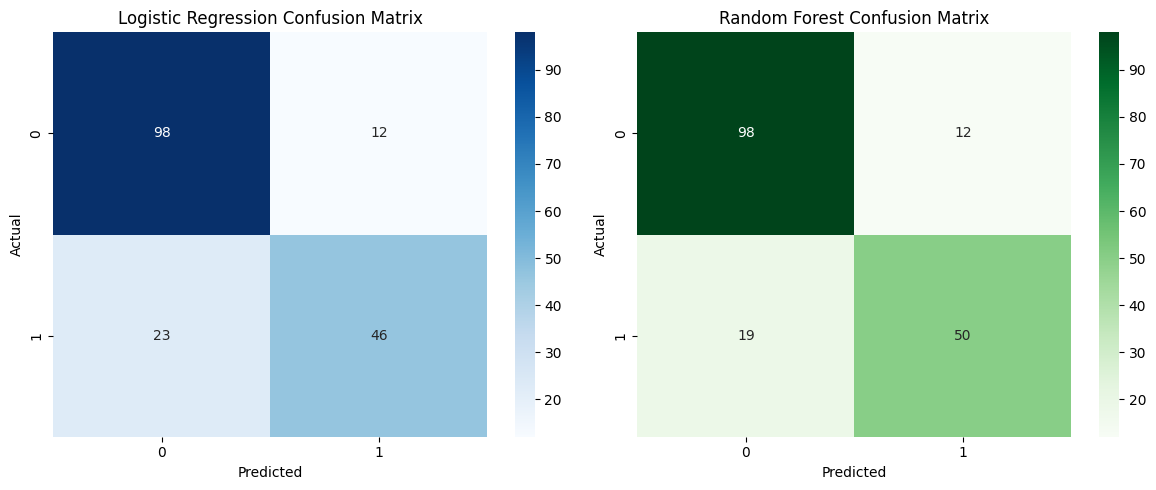

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
# Save the Random Forest model (better on this data)
joblib.dump(rf_model, 'titanic_model.pkl')
print("Model saved successfully as 'titanic_model.pkl'")

Model saved successfully as 'titanic_model.pkl'


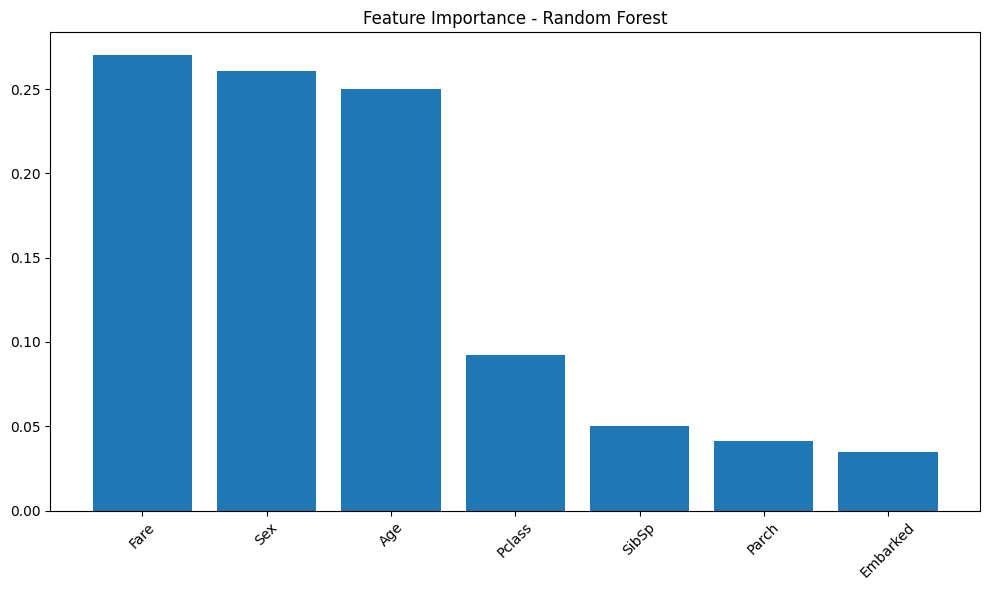

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance from Random Forest
importances = rf_model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]  # descending order

plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# Task 1 – Machine Learning Classification Project  
**Titanic Survival Prediction**

### Objective
Build and compare machine learning models to predict passenger survival on the Titanic (binary classification: 0 = did not survive, 1 = survived).

### Dataset & Preprocessing
- Source: Public Titanic dataset (891 samples)
- Features used: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
- Steps:
  - Removed irrelevant columns (PassengerId, Name, Ticket, Cabin)
  - Imputed missing values: Age → median, Embarked → mode ('S')
  - Encoded categorical variables: Sex (0/1), Embarked (0/1/2)
  - Train/test split: 80/20 stratified (712 train, 179 test)

### Models Trained
- **Logistic Regression** (baseline linear model)
- **Random Forest Classifier** (n_estimators=100)

### Test Set Performance Comparison

| Metric       | Logistic Regression | Random Forest | Winner       |
|--------------|----------------------|---------------|--------------|
| Accuracy     | 0.8045              | **0.8269**    | Random Forest |
| Precision    | 0.7931              | **0.8065**    | Random Forest |
| Recall       | 0.6667              | **0.7246**    | Random Forest |
| F1-Score     | 0.7244              | **0.7634**    | Random Forest |
| ROC-AUC      | **0.8520**          | 0.8278        | Logistic Regression |

### Key Observations
- Random Forest shows better overall performance, particularly higher **recall** and **F1-score** — meaning it identifies more actual survivors while maintaining good precision.
- Logistic Regression has a slight edge in ROC-AUC, indicating good ranking ability, but is outperformed in balanced classification metrics.
- Most influential features (from Random Forest): Sex, Fare, Age, Pclass

### Final Model
**Random Forest** selected as the production model due to superior balanced performance.

**Model artifact saved:** `titanic_model.pkl`  
(Ready for deployment in Task 3 – API & Containerization)

Prepared as part of InternSpark AI Internship – Task 1